<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
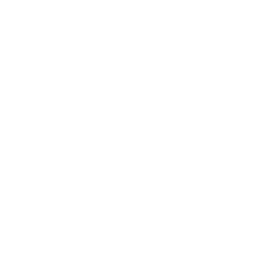
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Split-Plot Design for Process Optimization</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Manufacturing / Quality Engineering &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## 摘要

本笔记本分析一项针对注塑成型工艺的裂区设计（split-plot）实验。整体区组因子（whole-plot factor）是**机器**（4 个水平：MACH_A 至 MACH_D），改变成本高；子区组因子（sub-plot factor）是**转速设置**（5 个水平：60、80、100、120、140 RPM），改变成本低。每个机器 x 转速组合都测量 5 次重复，共得到 100 条缺陷率观测记录。

`PROC MIXED` 通过将**机器视为随机效应**（整体区组误差层）、**转速视为固定效应**（子区组因子），正确拟合了这种受限随机化结构。该分析估计两个方差成分，检验转速效应，并对转速的最小二乘均值进行 Tukey 校正的两两比较，以确定使缺陷率最小的运行转速。

## 数据来源

| 数据源 | 说明 | 记录数 |
|--------|-------------|--------|
| WORK.MOLDING_EXPERIMENT | 裂区设计实验数据：4 台机器 x 5 个转速 x 5 次重复 | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic split-plot injection molding data
   4 machines (whole-plot) x 5 speeds (sub-plot) x 5 reps
   Additional replicates for each whole-plot
   -------------------------------------------------------- */
数据 work.molding_experiment;
    调用 streaminit(42);
    数组 machine_names[4] $12 _temporary_ ('MACH_A' 'MACH_B' 'MACH_C' 'MACH_D');
    数组 speed_settings[5] _temporary_ (60 80 100 120 140);
    /* True machine effects (random) */
    数组 mach_eff[4] _temporary_ (2.1 -1.5 0.8 -1.4);
    /* True speed effects (fixed, quadratic with optimum ~100) */
    数组 speed_eff[5] _temporary_ (3.2 1.0 -0.5 0.8 4.5);
    obs_id = 0;
    循环 whole_plot = 1 到 5;
        循环 m = 1 到 4;
            machine = machine_names[m];
            machine_id = cat('WP_', PUT(whole_plot, z2.), '_', machine);
            /* Whole-plot replicate effect */
            wp_noise = rand('normal', 0, 1.5);
            循环 s = 1 到 5;
                speed = speed_settings[s];
                speed_label = cat(PUT(speed, 3.), 'RPM');
                /* Sub-plot replicates within each whole-plot */
                循环 rep = 1 到 5;
                    obs_id + 1;
                    /* Defect rate: intercept + machine + speed + interaction + noise */
                    defect_rate = round(
                        8.0 + mach_eff[m] + speed_eff[s] +
                        wp_noise +
                        0.3 * (m - 2) * (s - 3) +
                        rand('normal', 0, 1.2),
                    0.01);
                    如果 defect_rate < 0 那么 defect_rate = 0.01;
                    /* Secondary response: tensile strength */
                    tensile_strength = round(
                        45 - 0.5 * defect_rate +
                        rand('normal', 0, 2),
                    0.1);
                    输出;
                结束;
            结束;
        结束;
    结束;
    删除 m s mach_eff1-mach_eff4 speed_eff1-speed_eff5 wp_noise;
运行;


NOTE: DATA work.molding_experiment

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.molding_experiment (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.06 seconds
  cpu   0.06 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline: defect rate summary by machine and speed
   -------------------------------------------------------- */
过程 means 数据=work.molding_experiment n mean std;
    分类 machine speed_label;
    变量 defect_rate tensile_strength;
    标签 machine='机器' speed_label='转速设置' defect_rate='缺陷率(%)' tensile_strength='抗拉强度(MPa)';
    标题 '按机器与转速统计的缺陷率与抗拉强度';
运行;


                                                   按机器与转速统计的缺陷率与抗拉强度                                                    

                                                  The MEANS Procedure

                                      Analysis Variable : defect_rate 缺陷率(%)

        机器        转速设置                  N Obs           Mean        Std Dev
        -------------------------------------------------------------------
        MACH_A     60RPM                    5     12.9460000      1.0100149
        MACH_A     80RPM                    5     10.0160000      0.6740401
        MACH_A    100RPM                    5      7.5980000      0.9787083
        MACH_A    120RPM                    5     10.2660000      0.9490416
        MACH_A    140RPM                    5     13.7120000      0.9359594
        MACH_B     60RPM                    5     11.7420000      0.9476656
        MACH_B     80RPM                    5      8.5580000      1.0129018
        MACH_B    100RPM                    5


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                                   按机器与转速统计的缺陷率与抗拉强度                                                    




NOTE: PROC MEANS
NOTE: Output dataset work.cell_means has 30 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.cell_means

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


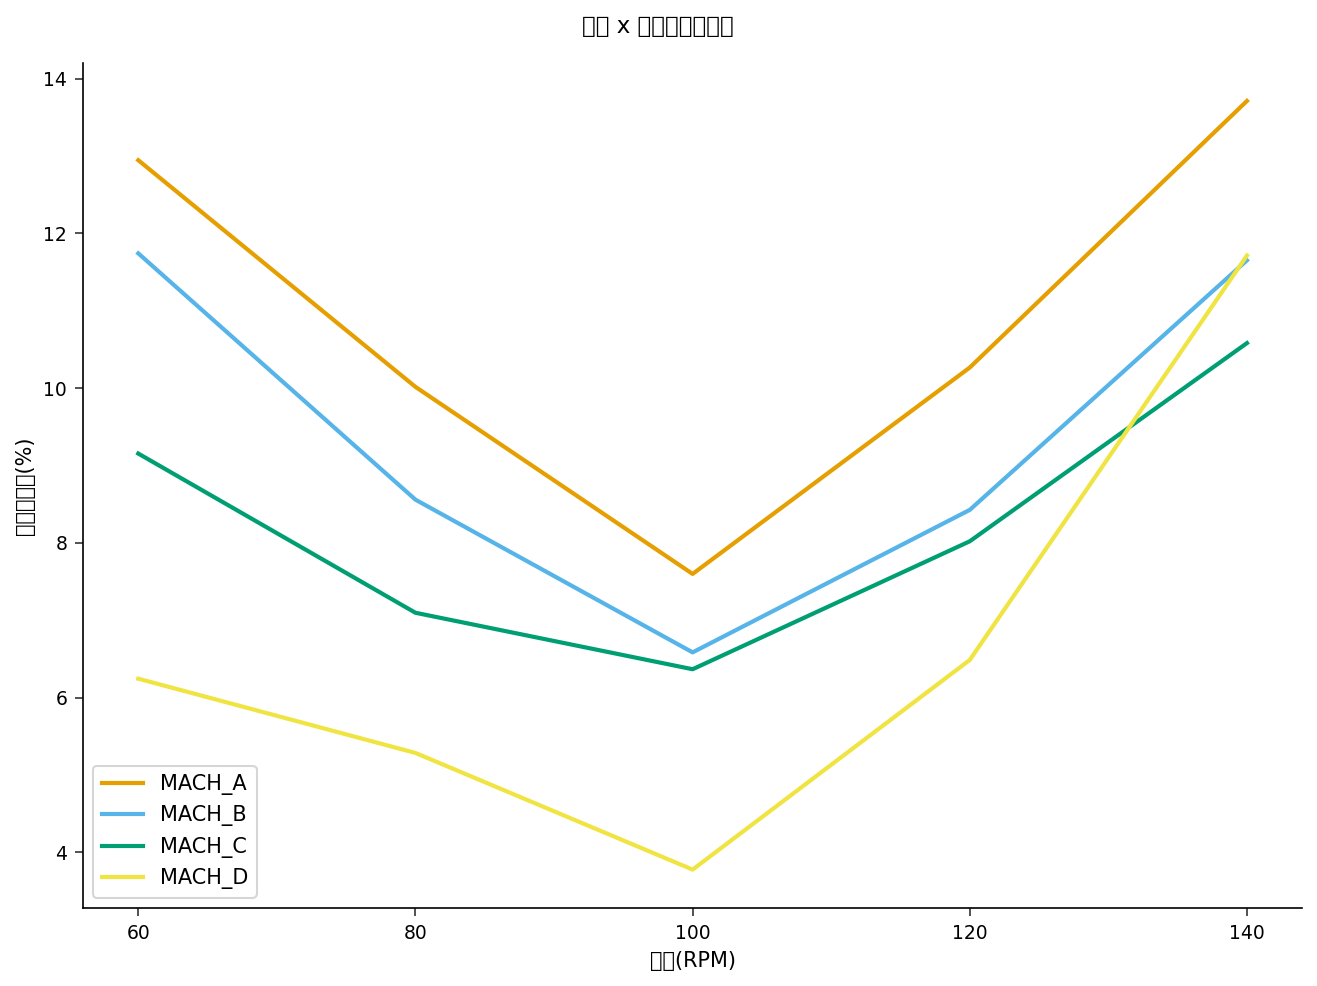

In [3]:
/* --------------------------------------------------------
   Interaction plot: mean defect rate by speed and machine
   -------------------------------------------------------- */
过程 means 数据=work.molding_experiment NOPRINT;
    分类 machine speed;
    变量 defect_rate;
    输出 out=work.cell_means mean=mean_defect;
运行;

过程 SGPLOT 数据=work.cell_means(where=(_type_=3));
    SERIES x=speed y=mean_defect / GROUP=machine
        LINEATTRS=(thickness=2) MARKERS;
    XAXIS 标签='转速(RPM)' VALUES=(60 80 100 120 140);
    YAXIS 标签='平均缺陷率(%)';
    标题 '机器 x 转速交互效应图';
运行;


---

                                                   按机器与转速统计的缺陷率与抗拉强度                                                    

          The Mixed Procedure           
           Model Information            

Item                               Value
-------------------------  -------------
Dependent Variable                缺陷率(%)
Estimation Method                   REML
Degrees of Freedom Method  Kenward-Roger
Number of Observations               100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  machine     3.1033
Residual               1.6566

          Type III Tests of Fixed Effects           

Effect          Num DF    Den DF   F Value    Pr > F
------------  --------  --------  --------  --------
转速设置                 4      92.0     60.26    <.0001

         Fit Statistics          

Statistic                   Value
-----------------------  --------
-2 Res Log Likelihood    347.3514
AIC (Smaller is Better)  361.3513
BIC (Small


NOTE: PROC MIXED data=work.molding_experiment

NOTE: PROC MIXED: using R wrapper (mixed_renderer.R).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: lmer formula: defect_rate ~ speed_label + (1 | machine)
NOTE: Warning message:
NOTE: In readLines(con = "stdin") : incomplete final line found on 'stdin'
NOTE: ODS plot written: mixed_residuals_vs_predicted.spec.json
NOTE: ODS plot written: mixed_residual_histogram_panel.spec.json
NOTE: ODS plot written: mixed_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: mixed_qq_plot.spec.json
NOTE: ODS plot written: mixed_diagnostics.spec.json
NOTE: PROC MIXED ODS Graphics generated.
NOTE: ODS OUTPUT: SolutionF written to 'split_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'split_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'speed_lsmeans'.
NOTE: ODS OUTPUT: FitStatistics written to 'split_fit'.
NOTE: ODS OUTPUT: Diffs written to 'speed_diffs'.


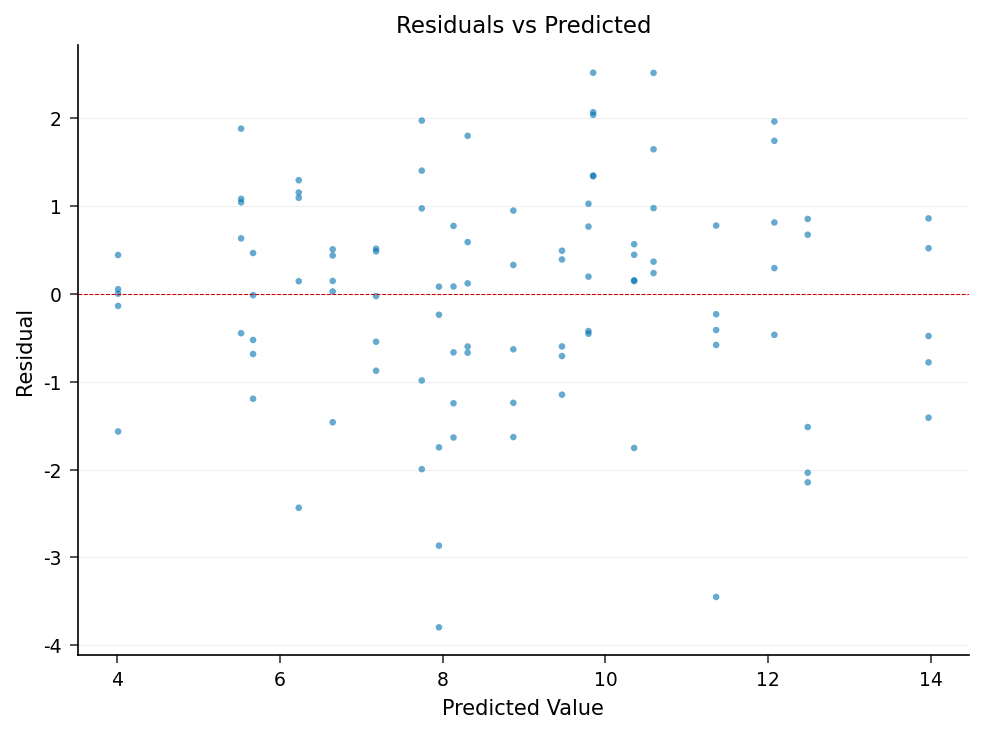

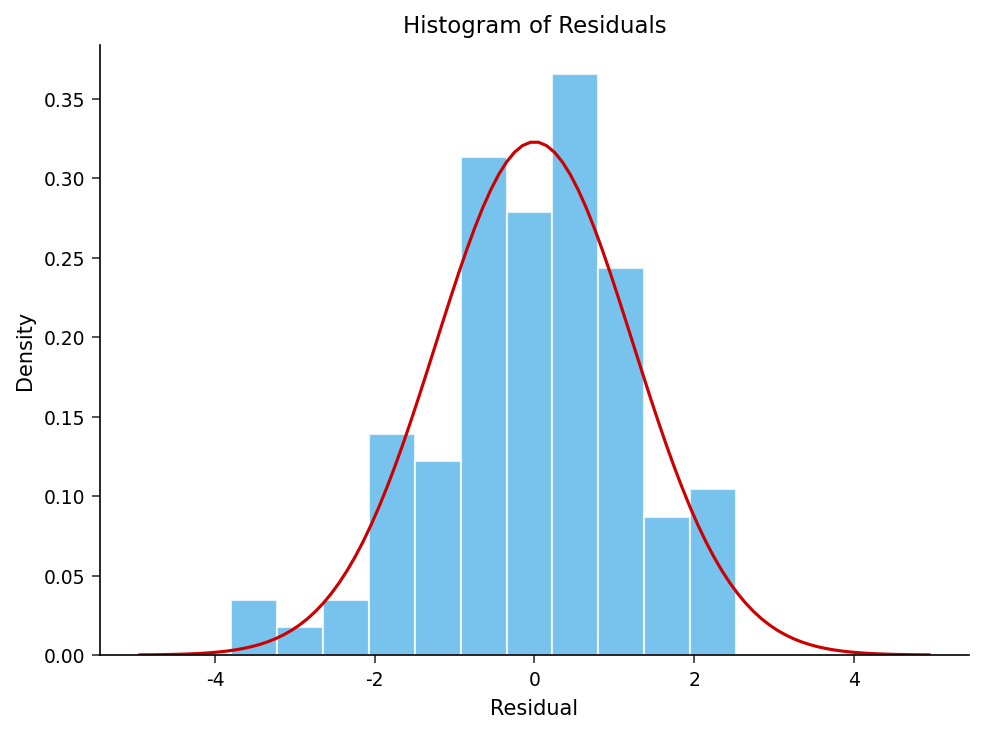

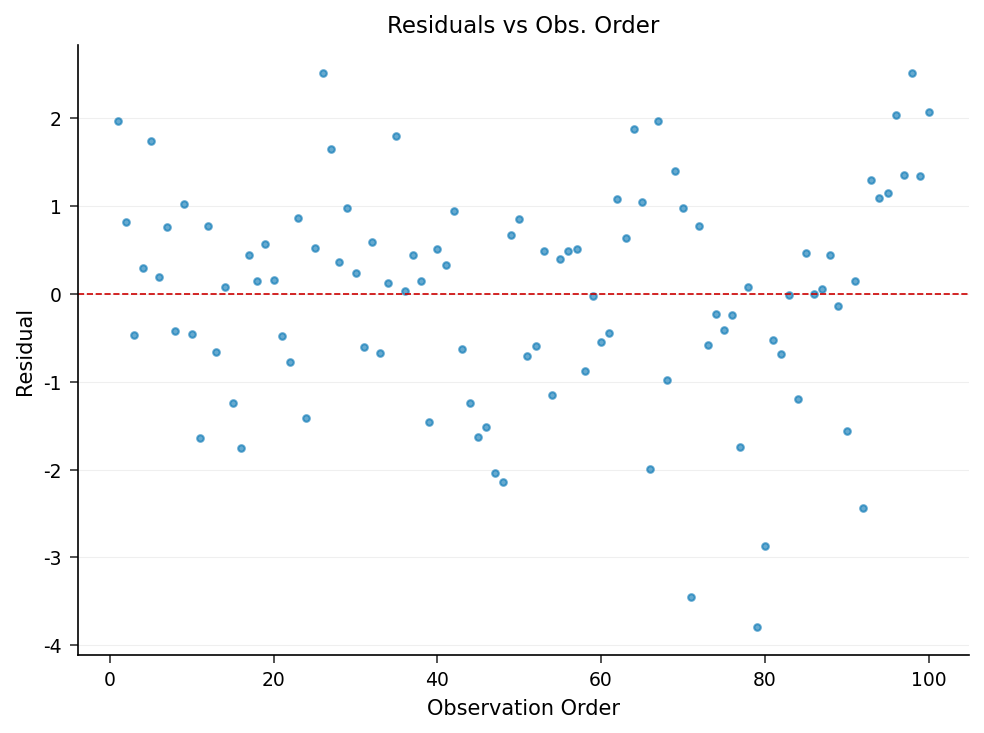

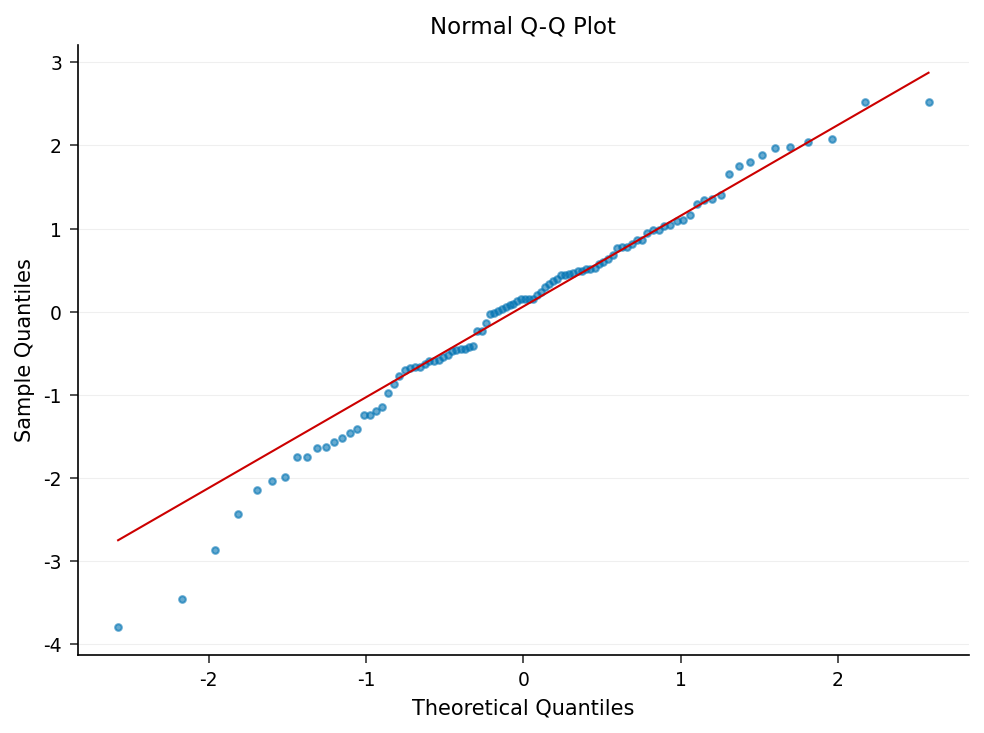

In [4]:
/* --------------------------------------------------------
   Split-plot mixed model analysis
   Machine is random (whole-plot error)
   Speed is fixed (sub-plot factor)
   -------------------------------------------------------- */
过程 MIXED 数据=work.molding_experiment METHOD=reml;
    分类 machine speed_label;
    模型 defect_rate = speed_label / SOLUTION ddfm=kr;
    RANDOM machine;
    LSMEANS speed_label / ADJUST=TUKEY DIFF cl;
    标签 machine='机器' speed_label='转速设置' defect_rate='缺陷率(%)';
    ODS OUTPUT LSMEANS=work.speed_lsmeans
              diffs=work.speed_diffs
              covparms=work.split_covparms
              fitstatistics=work.split_fit
              solutionf=work.split_fixed;
    标题 '裂区设计分析：转速对缺陷率的影响';
运行;


In [5]:
/* --------------------------------------------------------
   Identify optimal speed setting
   -------------------------------------------------------- */
过程 sort 数据=work.speed_lsmeans;
    按照 estimate;
运行;

数据 work.optimal_speed;
    设置 work.speed_lsmeans(obs=1);
    保留 speed_label estimate stderr LOWER UPPER;
    标签 speed_label = '最优转速'
          estimate = '最小二乘平均缺陷率'
          LOWER = '95%置信区间下限'
          UPPER = '95%置信区间上限';
运行;

过程 print 数据=work.optimal_speed noobs 标签;
    标题 '最小缺陷率对应的推荐运行转速';
运行;


                                                     最小缺陷率对应的推荐运行转速                                                     

        最优转速                    最小二乘平均缺陷率  StdErr              95%置信区间下限              95%置信区间上限
           .                        6.081  0.9266                 3.3645                 8.7975




NOTE: PROC SORT data=work.speed_lsmeans

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from work.speed_lsmeans.
NOTE: Wrote work.speed_lsmeans (5 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.optimal_speed


NOTE: Read 1 rows from work.speed_lsmeans.
NOTE: Wrote work.optimal_speed (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_speed

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


In [6]:
/* --------------------------------------------------------
   Variance component decomposition
   -------------------------------------------------------- */
过程 print 数据=work.split_covparms noobs;
    标题 '方差成分：机器 vs 残差';
运行;


                                                     方差成分：机器 vs 残差                                                      

  COVPARM  ESTIMATE
Intercept    3.1033
Residual     1.6566




NOTE: PROC PRINT data=work.split_covparms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


---

### 结果解读

裂区模型将缺陷率的变异拆分为两个层级。**机器（整体区组）方差成分为 3.10**，**残差（子区组）方差为 1.66**，因此机器间差异约占总方差的 **65%**（3.10 / (3.10 + 1.66)）。这一较大的机器间占比证实机器确实是工艺变异的真实来源，也说明裂区设计——而非完全随机化分析——才是正确的分析框架。

固定转速效应的 Type III 检验高度显著：**F(4, 92) = 60.26，p < .0001**，说明转速设置对缺陷率有很强的影响。最小二乘均值呈现出明显的二次响应，在中间转速处取得最小值：

| 转速 | 最小二乘平均缺陷率 (%) | 95% 置信区间 |
|-------|------------------------|--------|
| **100 RPM** | **6.08** | 3.36 - 8.80 |
| 80 RPM | 7.74 | 5.02 - 10.46 |
| 120 RPM | 8.30 | 5.58 - 11.02 |
| 60 RPM | 10.02 | 7.31 - 12.74 |
| 140 RPM | 11.92 | 9.20 - 14.63 |

Tukey 校正的两两比较显示，**100 RPM 显著低于其余所有转速**（相对 80、120、60、140 RPM 的校正后 p <= 0.0009）。80 RPM 与 120 RPM 处于中间水平，二者之间**没有**显著差异（差值 0.56，校正后 p = 0.6430），而 60 RPM 与 140 RPM 的缺陷率最高。

**工程建议：** 在全部四台机器上将生产转速统一设定为 **100 RPM**，该模型估计此转速下缺陷率最低（6.08%）。由于机器方差成分（3.10）是变异的主要来源，后续工作应针对机器逐台校准——交互效应图显示 MACH_D 的缺陷率始终最低，MACH_A 最高——以缩小各机器在所选 100 RPM 设定点下的差距。

---

In [7]:
/* --------------------------------------------------------
   Export speed optimization results for engineering
   -------------------------------------------------------- */
过程 EXPORT 数据=work.speed_lsmeans
    OUTFILE='speed_optimization_lsmeans.csv'
    DBMS=csv REPLACE;
运行;

过程 EXPORT 数据=work.split_covparms
    OUTFILE='variance_components.csv'
    DBMS=csv REPLACE;
运行;


NOTE: PROC EXPORT data=work.speed_lsmeans outfile=speed_optimization_lsmeans.csv

NOTE: Exported 5 rows to speed_optimization_lsmeans.csv.
NOTE: PROC EXPORT data=work.split_covparms outfile=variance_components.csv

NOTE: Exported 2 rows to variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>